In [1]:
import os

import numpy as np
import pandas as pd
import pyBigWig
import matplotlib.pyplot as plt

In [2]:
NOTEBOOK_DIR = os.getcwd()
REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))

RESULTS = os.path.join(REPO_ROOT, "results")
MY_BIGWIG = os.path.join(RESULTS, "pseudobulk", "bigwig")
FIGURES = os.path.join(RESULTS, "figures")
os.makedirs(FIGURES, exist_ok=True)

# Csf1r locus on mm10. The FIRE enhancer is an intronic regulatory element
# of Csf1r, specifically accessible in microglia.
CSF1R_PROMOTER = ("chr18", 61105628, 61105973)
FIRE_ENHANCER = ("chr18", 61108475, 61108975)

# Context view: the whole Csf1r region, as shown in the published figure
CONTEXT_REGION = ("chr18", 61100000, 61118000)

# Cell types in plotting order, microglia first
CELL_TYPES = [
    "Microglia",
    "Astrocytes",
    "Oligodendrocytes",
    "OPC",
    "Endothelial",
    "Excitatory_neurons",
    "Inhibitory_neurons",
]

for ct in CELL_TYPES:
    path = os.path.join(MY_BIGWIG, f"{ct}.bw")
    print(f"{'OK' if os.path.exists(path) else 'MISSING':8s} {ct}")

OK       Microglia
OK       Astrocytes
OK       Oligodendrocytes
OK       OPC
OK       Endothelial
OK       Excitatory_neurons
OK       Inhibitory_neurons


In [3]:
def extract_signal(bigwig_path, chrom, start, end, n_bins=None):
    """Return per-base or binned signal for a genomic interval."""
    bw = pyBigWig.open(bigwig_path)
    if n_bins is None:
        values = np.array(bw.values(chrom, start, end), dtype=float)
    else:
        values = np.array(bw.stats(chrom, start, end, nBins=n_bins, type="mean"), dtype=float)
    bw.close()
    return np.nan_to_num(values, nan=0.0)


chrom, start, end = CONTEXT_REGION
signals = {
    ct: extract_signal(os.path.join(MY_BIGWIG, f"{ct}.bw"), chrom, start, end)
    for ct in CELL_TYPES
}

print(f"Region: {chrom}:{start:,}-{end:,} ({end - start:,} bp)")
print()
for ct, sig in signals.items():
    print(f"  {ct:20s} max={sig.max():7.2f}  mean={sig.mean():6.3f}")

Region: chr18:61,100,000-61,118,000 (18,000 bp)

  Microglia            max=  11.53  mean= 1.126
  Astrocytes           max=   0.52  mean= 0.051
  Oligodendrocytes     max=   0.47  mean= 0.050
  OPC                  max=   0.52  mean= 0.083
  Endothelial          max=   0.74  mean= 0.067
  Excitatory_neurons   max=   0.36  mean= 0.067
  Inhibitory_neurons   max=   0.74  mean= 0.095


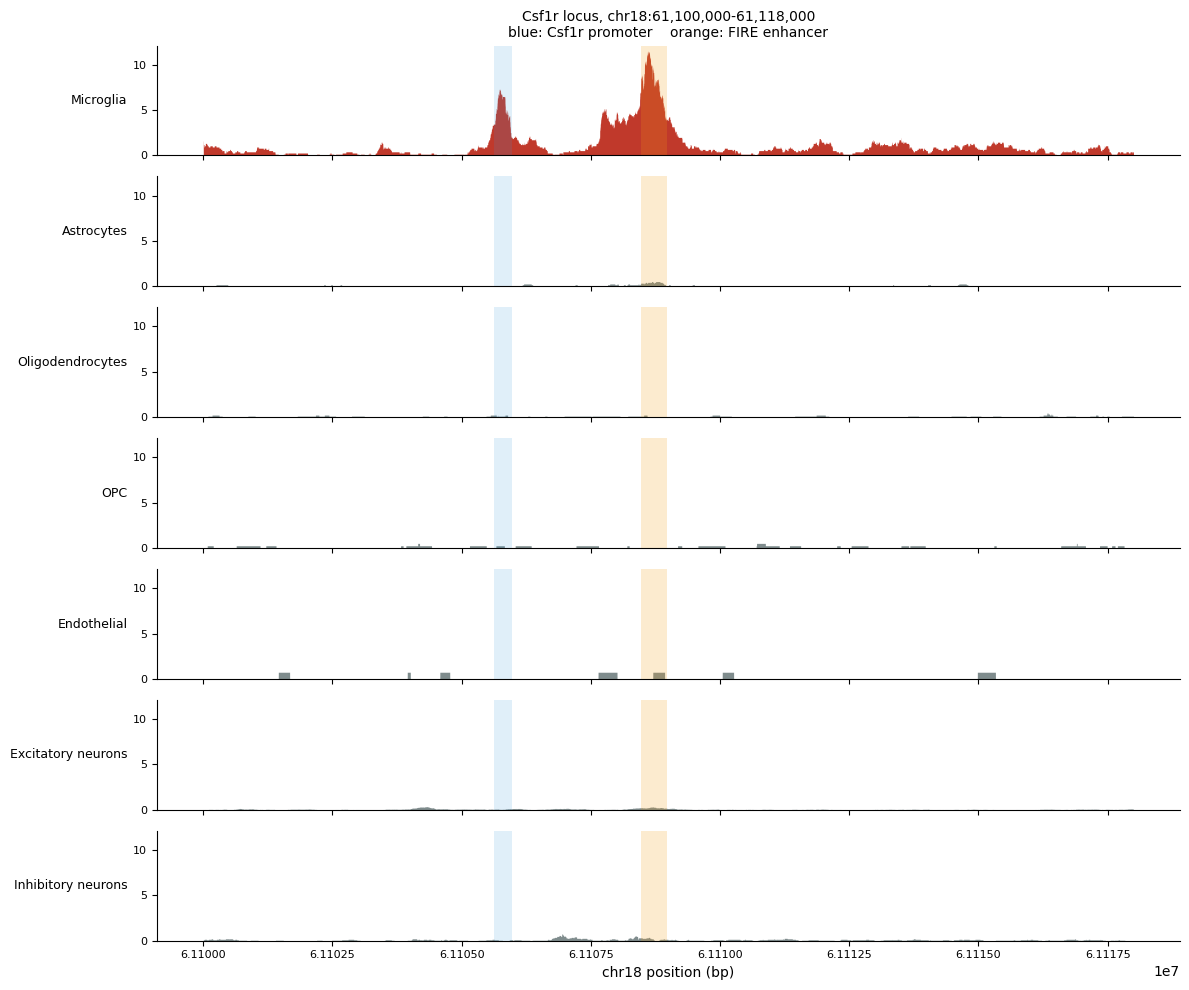

In [4]:
fig, axes = plt.subplots(len(CELL_TYPES), 1, figsize=(12, 10), sharex=True, sharey=True)
positions = np.arange(start, end)

# Shared y scale, so track heights are directly comparable
ymax = max(sig.max() for sig in signals.values()) * 1.05

for ax, ct in zip(axes, CELL_TYPES):
    color = "#c0392b" if ct == "Microglia" else "#7f8c8d"
    ax.fill_between(positions, signals[ct], color=color, linewidth=0)
    ax.set_ylim(0, ymax)
    ax.set_ylabel(ct.replace("_", " "), rotation=0, ha="right", va="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

# Highlight the promoter and the FIRE enhancer across all tracks
for ax in axes:
    ax.axvspan(CSF1R_PROMOTER[1], CSF1R_PROMOTER[2], color="#3498db", alpha=0.15, linewidth=0)
    ax.axvspan(FIRE_ENHANCER[1], FIRE_ENHANCER[2], color="#f39c12", alpha=0.20, linewidth=0)

axes[-1].set_xlabel(f"{chrom} position (bp)")
axes[0].set_title(
    f"Csf1r locus, {chrom}:{start:,}-{end:,}\n"
    "blue: Csf1r promoter    orange: FIRE enhancer",
    fontsize=10,
)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "fire_context.png"), dpi=150, bbox_inches="tight")
plt.show()

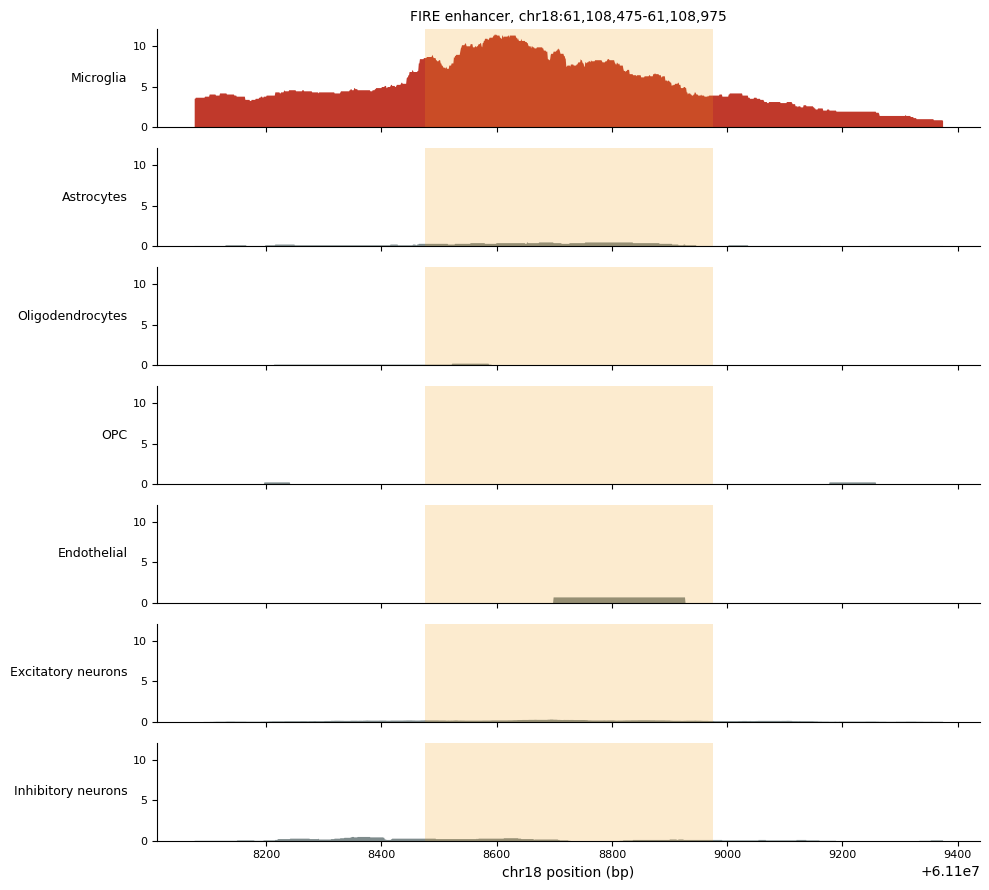

Signal within the FIRE enhancer:
  Microglia            max=  11.53  mean= 8.130
  Astrocytes           max=   0.52  mean= 0.387
  Oligodendrocytes     max=   0.23  mean= 0.042
  OPC                  max=   0.00  mean= 0.000
  Endothelial          max=   0.74  mean= 0.339
  Excitatory_neurons   max=   0.34  mean= 0.238
  Inhibitory_neurons   max=   0.37  mean= 0.185


In [5]:
# Detail view: 1.3 kb window centred on the FIRE enhancer
fire_chrom, fire_start, fire_end = FIRE_ENHANCER
pad = 400
zoom_start, zoom_end = fire_start - pad, fire_end + pad

zoom_signals = {
    ct: extract_signal(os.path.join(MY_BIGWIG, f"{ct}.bw"), fire_chrom, zoom_start, zoom_end)
    for ct in CELL_TYPES
}

fig, axes = plt.subplots(len(CELL_TYPES), 1, figsize=(10, 9), sharex=True, sharey=True)
zoom_positions = np.arange(zoom_start, zoom_end)
zoom_ymax = max(sig.max() for sig in zoom_signals.values()) * 1.05

for ax, ct in zip(axes, CELL_TYPES):
    color = "#c0392b" if ct == "Microglia" else "#7f8c8d"
    ax.fill_between(zoom_positions, zoom_signals[ct], color=color, linewidth=0)
    ax.axvspan(fire_start, fire_end, color="#f39c12", alpha=0.20, linewidth=0)
    ax.set_ylim(0, zoom_ymax)
    ax.set_ylabel(ct.replace("_", " "), rotation=0, ha="right", va="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel(f"{fire_chrom} position (bp)")
axes[0].set_title(
    f"FIRE enhancer, {fire_chrom}:{fire_start:,}-{fire_end:,}",
    fontsize=10,
)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "fire_zoom.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Signal within the FIRE enhancer:")
for ct in CELL_TYPES:
    sig = extract_signal(os.path.join(MY_BIGWIG, f"{ct}.bw"), fire_chrom, fire_start, fire_end)
    print(f"  {ct:20s} max={sig.max():7.2f}  mean={sig.mean():6.3f}")